# 02 Baseline structure of the HLJ1-ERAD network

**Question.** In the intact yeast network, which proteins connect HLJ1 to the other core ERAD proteins, and which proteins show broader proximity to this seed set?

Notebook 01 fixed the STRING release, input files, protein identifiers, 6 core seeds, and analysis thresholds. Here we use those choices without changing them.

- Primary network: STRING functional associations, combined score ≥ 700.
- Threshold sensitivity: functional associations at scores ≥ 400 and ≥ 900.
- Evidence coverage: STRING physical network at score ≥ 700.
- Anchor: HLJ1, denoted $h$.
- Surviving pathway seeds: $S=R\setminus\{h\}$, where $R$ is the six-protein core seed set.

**Outputs**

1. Pairwise distances among the 6 core seeds.
2. One baseline-feature row per STRING protien.
3. Threshold and physical-evidence summaries.
4. A figure showing HLJ1, the other seeds, and proteins on their shortest paths.

Network position produces **candidate hypotheses**. It does not establish that deleting H:J1 changes a protein's abundance, activity, or expression. STRING's combined score measures confidence in an association, not interaction strength or effect size.

In [1]:
from pathlib import Path
from collections import defaultdict, deque
from itertools import combinations
import hashlib
import json
import math
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RAW = ROOT / "data" / "raw" / "string_v12_0"
PROCESSED = ROOT / "data" / "processed" / "string_v12_0"
META = ROOT / "data" / "metadata"
OUTPUT = ROOT / "outputs" / "notebook_02"
FIGURES = ROOT / "figures"

OUTPUT.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

DESIGN_PATH = META / "string_analysis_design_v12_0.json"
SEED_PATH = META / "erad_seeds.csv"
ID_MAP_PATH = PROCESSED / "string_id_to_orf.csv"
SUMMARY_PATH = PROCESSED / "network_threshold_summary.csv"

def sha256(path, block_size=1024 * 1024):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(block_size), b""):
            digest.update(block)
    return digest.hexdigest()

design = json.loads(DESIGN_PATH.read_text("utf-8"))

assert design["string_release"] == "12.0"
assert design["taxon_id"] == 4932
assert design["primary_layer"] == "functional"
assert design["primary_score_threshold"] == 700
assert sorted(design["sensitivity_thresholds"]) == [400, 900]
assert sha256(SEED_PATH) == design["seed_table_sha256"]

RAW_FILES = {
    "functional": RAW / "4932.protein.links.full.v12.0.txt.gz",
    "physical": RAW / "4932.protein.physical.links.full.v12.0.txt.gz",
    "info": RAW / "4932.protein.info.v12.0.txt.gz",
    "aliases": RAW / "4932.protein.aliases.v12.0.txt.gz",
}

for role, path in RAW_FILES.items():
    assert path.is_file(), f"Missing frozen input: {path}"
    assert sha256(path) == design["raw_file_sha256"][role], (
        f"Frozen input changed: {path}"
    )

print("Frozen Notebook 01 inputs verified.")

Frozen Notebook 01 inputs verified.


## 1. Construct the fixed primary graph

Let $G=(V,E)$ be a simple, undirected graph. Every protein in the STRING identifier table is a vertex, including proteins with no retained edges.

For an edge $\{i,j\}$, define its confidence weight and path cost as

$$w_{ij}=\frac{c_{ij}}{1000},\quad\ell_{ij}=-\log{w_{ij}}$$

where $c_{ij}$ is the STRING combined score. The weighted adjacency matrix is $W=(w_{ij})_{i,j\in V}$; the binary adjacency matrix is $A=(1_{\{i,j\}\in E})_{i,j\in V}$.

The cost convention makes a high-confidence edge shorter. It is an **analysis convention**, not a model of how a biological effect propagates.

In [3]:
id_map = pd.read_csv(ID_MAP_PATH, dtype=str).fillna("")
seeds = pd.read_csv(SEED_PATH, dtype=str).fillna("")
network_summary = pd.read_csv(SUMMARY_PATH)

assert id_map["string_protein_id"].is_unique
assert seeds["orf"].is_unique

core = seeds.loc[seeds["set"] == "core"].copy()
assert sorted(core["orf"]) == design["core_seed_orfs"]

seed_map = id_map.loc[
    id_map["orf"].isin(core["orf"]),
    ["orf", "string_protein_id", "preferred_name", "mapping_status"],
].copy()

assert seed_map["orf"].is_unique, "A core ORF has multiple STRING mappings."
assert set(seed_map["orf"]) == set(core["orf"])
assert seed_map["mapping_status"].eq("string_id").all()

R = set(seed_map["string_protein_id"])
h = design["hlj1_string_id"]
S = R - {h}

assert h in R
assert len(R) == 6
assert len(S) == 5

all_ids = set(id_map["string_protein_id"])
name_by_id = dict(zip(
    id_map["string_protein_id"],
    id_map["preferred_name"],
))

def read_edges(layer):
    path = PROCESSED / f"{layer}_edges_score_ge_400.csv.gz"
    frame = pd.read_csv(path, usecols=["u", "v", "combined_score"])
    return frame.loc[:, ["u", "v", "combined_score"]]

def build_graph(edges, cutoff):
    selected = edges.loc[
        edges["combined_score"] >= cutoff,
        ["u", "v", "combined_score"],
    ]

    assert selected["combined_score"].between(cutoff, 1000).all()
    assert selected[["u", "v"]].duplicated().sum() == 0
    assert not (selected["u"] == selected["v"]).any()
    assert set(selected["u"]) | set(selected["v"]) <= all_ids

    graph = nx.Graph()
    graph.add_nodes_from(id_map["string_protein_id"])

    graph.add_edges_from(
        (u, v, {"confidence": score / 1000, "length": -math.log(score / 1000)})
        for u, v, score in selected.itertuples(index=False, name=None)
    )
    return graph

functional_edges = read_edges("functional")
G = build_graph(functional_edges, cutoff=700)

expected = network_summary.loc[
    (network_summary["layer"] == "functional")
    & np.isclose(network_summary["threshold"], 0.7)
].iloc[0]

assert G.number_of_nodes() == int(expected["nodes"])
assert G.number_of_edges() == int(expected["edges"])
assert G.degree(h) == int(expected["HLJ1_degree"])

print(
    f"Primary graph: {G.number_of_nodes():,} proteins, "
    f"{G.number_of_edges():,} associations"
)
print(f"HLJ1 degree: {G.degree(h)}")
display(seed_map.sort_values("orf"))

Primary graph: 6,600 proteins, 104,188 associations
HLJ1 degree: 25


,orf,string_protein_id,preferred_name,mapping_status
492,YBR201W,4932.YBR201W,DER1,string_id
4269,YLR207W,4932.YLR207W,HRD3,string_id
4722,YMR022W,4932.YMR022W,UBC7,string_id
4871,YMR161W,4932.YMR161W,HLJ1,string_id
4984,YMR264W,4932.YMR264W,CUE1,string_id
5504,YOL013C,4932.YOL013C,HRD1,string_id


## 2. Measure distances among the fixed seeds

The **hop distance** $d^{\text{hop}}_G(i,j)$ is the minimum number of edges on a path from $i$ to $j$.

The **confidence-path distance** is

$$d^{\text{conf}}_G(i,j)=\min_{\pi:i\leadsto j}\sum_{\{u,v\}\in\pi}-\log(w_{uv}).$$

For disconnected proteins, distance is infinite; in exported tables it will appear as a missing value. We report both definitions because a shortest path by hops need not be shortest by confidence cost.

In [4]:
seed_ids = seed_map.sort_values("orf")["string_protein_id"].tolist()

hop_from_seed = {
    source: nx.single_source_shortest_path_length(G, source)
    for source in seed_ids
}
cost_from_seed = {
    source: nx.single_source_dijkstra_path_length(
        G, source, weight="length"
    )
    for source in seed_ids
}

seed_pair_rows = []
for a, b in combinations(seed_ids, 2):
    seed_pair_rows.append({
        "protein_a": a,
        "name_a": name_by_id.get(a, a),
        "protein_b": b,
        "name_b": name_by_id.get(b, b),
        "hop_distance": hop_from_seed[a].get(b, np.nan),
        "confidence_path_cost": cost_from_seed[a].get(b, np.nan),
    })

seed_distances = pd.DataFrame(seed_pair_rows)
display(seed_distances)

hlj1_to_S = seed_distances.loc[
    (seed_distances["protein_a"] == h)
    | (seed_distances["protein_b"] == h)
]
print("HLJ1-to-other-seed pairs:")
display(hlj1_to_S)

,protein_a,name_a,protein_b,name_b,hop_distance,confidence_path_cost
0,4932.YBR201W,DER1,4932.YLR207W,HRD3,1,0.001001
1,4932.YBR201W,DER1,4932.YMR022W,UBC7,1,0.002001
2,4932.YBR201W,DER1,4932.YMR161W,HLJ1,2,0.084652
3,4932.YBR201W,DER1,4932.YMR264W,CUE1,1,0.003002
4,4932.YBR201W,DER1,4932.YOL013C,HRD1,1,0.001001
5,4932.YLR207W,HRD3,4932.YMR022W,UBC7,1,0.002001
6,4932.YLR207W,HRD3,4932.YMR161W,HLJ1,2,0.084652
7,4932.YLR207W,HRD3,4932.YMR264W,CUE1,1,0.003002
8,4932.YLR207W,HRD3,4932.YOL013C,HRD1,1,0.001001
9,4932.YMR022W,UBC7,4932.YMR161W,HLJ1,2,0.085653


HLJ1-to-other-seed pairs:


,protein_a,name_a,protein_b,name_b,hop_distance,confidence_path_cost
2,4932.YBR201W,DER1,4932.YMR161W,HLJ1,2,0.084652
6,4932.YLR207W,HRD3,4932.YMR161W,HLJ1,2,0.084652
9,4932.YMR022W,UBC7,4932.YMR161W,HLJ1,2,0.085653
12,4932.YMR161W,HLJ1,4932.YMR264W,CUE1,2,0.085653
13,4932.YMR161W,HLJ1,4932.YOL013C,HRD1,2,0.084652


## 3. Compute complementary protein features

For each protein $v$, record different kinds of network evidence separately:

- **Degree:** $k_v=\sum_j A_{vj}$, the number of retained neighbours.
- **Strength:** $s_v=\sum_j w_{vj}$, the sum of confidence weights.
- **Global PageRank:** importance in the full association graph.
- **ERAD-personalized PageRank:** proximity in a random walk that restarts uniformly at the five seeds in $S$, excluding HLJ1.
- **Jaccard overlap:** similarity between the neighbour sets of $v$ and the seeds.
- **HLJ1-to-seed bridge score:** the fraction of shortest HLJ1-to-seed paths that pass through $v$.

For personalized PageRank, let the restart vector $\mathbf r$ assign $1/|S|$ to each seed in $S$, and zero elsewhere. With $\alpha=0.85$,

$$\mathbf p^{S} =\alpha P^\top\mathbf p^{S}+(1-\alpha)\mathbf r,$$

where $P$ is the transition matrix formed from edge confidence weights. Its isolated-node rows use $\mathbf r$.

For neighbour sets $N(v)$ and $N(s)$,

$$J(v,s)=\frac{|N(v)\cap N(s)|}{|N(v)\cup N(s)|},$$

with $J=0$ when the union is empty. We retain both the mean and maximum over $s\in S$.

For a non-seed protein $v$, define

$$B_{hS}(v)=\frac{1}{|S|}\sum_{s\in S}\frac{\sigma_{hs}(v)}{\sigma_{hs}},$$

where $\sigma_{hs}$ counts minimum-hop paths from HLJ1 to seed $s$, and $\sigma_{hs}(v)$ counts those passing through $v$. An unreachable seed contributes zero. This is a **targeted bridge measure**, not whole-network betweenness.

In [5]:
def bfs_distances_and_counts(graph, source):
    """Minimum-hop distances and number of minimum-hop paths from source."""
    distance = {source: 0}
    count = {source: 1}
    queue = deque([source])

    while queue:
        u = queue.popleft()

        for v in graph[u]:
            if v not in distance:
                distance[v] = distance[u] + 1
                count[v] = 0
                queue.append(v)

            if distance[v] == distance[u] + 1:
                count[v] += count[u]
    return distance, count

def hlj1_seed_bridge_scores(graph, h, S, R):
    """
    Fraction of shortest h-to-seed paths through each non-seed protein.
    The denominator is always the fixed number of surviving seeds.
    """
    distance_h, count_h = bfs_distances_and_counts(graph, h)
    bridge = defaultdict(float)

    for seed in S:
        if seed not in distance_h:
            continue

        distance_s, count_s = bfs_distances_and_counts(graph, seed)
        total_paths = count_h[seed]

        for v in distance_h.keys() & distance_s.keys():
            if v in R:
                continue

            lies_on_shortest_path = (
                distance_h[v] + distance_s[v] == distance_h[seed]
            )
            if lies_on_shortest_path:
                fraction = (
                    count_h[v] * count_s[v] / total_paths
                )
                bridge[v] += fraction / len(S)

    return dict(bridge), distance_h, count_h

bridge_700, h_hops, h_path_counts = hlj1_seed_bridge_scores(
    G, h, S, R
)

S_hops = nx.multi_source_dijkstra_path_length(G, S, weight=None)
h_cost = nx.single_source_dijkstra_path_length(G, h, weight="length")
S_cost = nx.multi_source_dijkstra_path_length(G, S, weight="length")

global_pagerank = nx.pagerank(
    G,
    alpha=0.85,
    weight="confidence",
    tol=1e-12,
    max_iter=500,
)

restart = {seed: 1 / len(S) for seed in S}
seed_pagerank = nx.pagerank(
    G,
    alpha=0.85,
    personalization=restart,
    dangling=restart,
    weight="confidence",
    tol=1e-12,
    max_iter=500,
)

seed_neighbours = [set(G[seed]) for seed in S]
jaccard_mean = {}
jaccard_max = {}

for v in G:
    neighbours_v = set(G[v])
    values = []

    for neighbours_seed in seed_neighbours:
        union = neighbours_v | neighbours_seed
        value = (
            len(neighbours_v & neighbours_seed) / len(union)
            if union else 0.0
        )
        values.append(value)

    jaccard_mean[v] = float(np.mean(values))
    jaccard_max[v] = float(max(values))

print("Proteins on at least one shortest HLJ1-to-seed path:")
display(
    pd.DataFrame(
        [
            {
                "string_protein_id": protein,
                "name": name_by_id.get(protein, protein),
                "bridge_hS": score,
            }
            for protein, score in bridge_700.items()
        ]
    ).sort_values("bridge_hS", ascending=False)
)

Proteins on at least one shortest HLJ1-to-seed path:


,string_protein_id,name,bridge_hS
0,4932.YIL030C,SSM4,0.6
1,4932.YJL034W,KAR2,0.4


## 4. Add community context

A community algorithm groups proteins whose within-group connections are relatively dense. We run weighted Louvain once on the **full primary graph**, with a fixed random seed.

Community membership is supporting context, not a prediction of deletion sensitivity. Community numbers are labels assigned by this run; their numeric values have no biological meaning. In particular, two proteins can be only two hops apart yet belong to different communities.

Louvain is a heuristic, so its partition may change with threshold or method. We do not use a community label as a sole reason to shortlist a protein.

In [6]:
communities = sorted(
    nx.community.louvain_communities(
        G,
        weight="confidence",
        seed=3888,
    ),
    key=lambda group: (-len(group), min(group)),
)

community_of = {}
community_size = {}

for community_number, members in enumerate(communities, start=1):
    for protein in members:
        community_of[protein] = community_number
        community_size[protein] = len(members)

assert len(community_of) == G.number_of_nodes()

seed_community_ids = {community_of[seed] for seed in S}

seed_communities = seed_map.copy()
seed_communities["community_id"] = seed_communities["string_protein_id"].map(community_of)
seed_communities["community_size"] = seed_communities["string_protein_id"].map(community_size)

print(f"Communities: {len(communities)}")
print("Weighted modularity:",round(
    nx.community.modularity(G, communities, weight="confidence"),
    4,
))
display(seed_communities.sort_values("orf"))

Communities: 860
Weighted modularity: 0.6282


,orf,string_protein_id,preferred_name,mapping_status,community_id,community_size
492,YBR201W,4932.YBR201W,DER1,string_id,9,291
4269,YLR207W,4932.YLR207W,HRD3,string_id,9,291
4722,YMR022W,4932.YMR022W,UBC7,string_id,9,291
4871,YMR161W,4932.YMR161W,HLJ1,string_id,4,435
4984,YMR264W,4932.YMR264W,CUE1,string_id,9,291
5504,YOL013C,4932.YOL013C,HRD1,string_id,9,291


In [7]:
profile = id_map.loc[
    :,
    ["string_protein_id", "orf", "preferred_name", "mapping_status"],
].copy()

profile = (
    profile.sort_values("string_protein_id")
    .reset_index(drop=True)
)

ids = profile["string_protein_id"]

profile["is_core_seed"] = ids.isin(R)
profile["is_HLJ1"] = ids.eq(h)

# KAR2 is the planned stress-response readout; YDJ1 is a
# prespecified comparison protein. Show them, but do not present
# them as newly discovered candidates.
profile["is_prespecified_readout"] = profile["preferred_name"].isin(["KAR2", "YDJ1"])
profile["candidate_eligible"] = ~profile["is_core_seed"] & ~profile["is_prespecified_readout"]

profile["degree"] = ids.map(dict(G.degree)).astype(int)
profile["strength"] = ids.map(dict(G.degree(weight="confidence")))
profile["global_pagerank"] = ids.map(global_pagerank)
profile["seed_pagerank"] = ids.map(seed_pagerank)

# Missing values mean "unreachable", not zero distance.
profile["h_hops"] = ids.map(h_hops)
profile["S_hops"] = ids.map(S_hops)
profile["h_confidence_cost"] = ids.map(h_cost)
profile["S_confidence_cost"] = ids.map(S_cost)

profile["jaccard_S_mean"] = ids.map(jaccard_mean)
profile["jaccard_S_max"] = ids.map(jaccard_max)
profile["bridge_hS"] = ids.map(bridge_700).fillna(0.0)

profile["direct_HLJ1"] = ids.map(
    lambda protein: G.has_edge(protein, h)
)
profile["direct_S_neighbours"] = ids.map(
    lambda protein: len(set(G[protein]) & S)
)

profile["community_id"] = ids.map(community_of)
profile["community_size"] = ids.map(community_size)
profile["same_community_as_HLJ1"] = ids.map(lambda protein: community_of[protein] == community_of[h])
profile["shares_S_community"] = ids.map(lambda protein: community_of[protein] in seed_community_ids)

display(
    profile.loc[
        profile["is_core_seed"]
        | profile["is_prespecified_readout"],
        [
            "orf",
            "preferred_name",
            "degree",
            "h_hops",
            "S_hops",
            "seed_pagerank",
            "bridge_hS",
            "community_id",
        ],
    ]
)

,orf,preferred_name,degree,h_hops,S_hops,seed_pagerank,bridge_hS,community_id
492,YBR201W,DER1,22,2.0,0.0,0.039805,0.0,9
3260,YJL034W,KAR2,94,1.0,1.0,0.009701,0.4,4
4269,YLR207W,HRD3,22,2.0,0.0,0.040302,0.0,9
4722,YMR022W,UBC7,24,2.0,0.0,0.039768,0.0,9
4871,YMR161W,HLJ1,25,0.0,2.0,0.000526,0.0,4
4984,YMR264W,CUE1,26,2.0,0.0,0.039415,0.0,9
5121,YNL064C,YDJ1,67,2.0,2.0,0.001059,0.0,4
5504,YOL013C,HRD1,36,2.0,0.0,0.042017,0.0,9


## 5. Check threshold robustness and physical-evidence coverage

Recalculate the shortest-path bridge measure at functional thresholds 400 and 900. A candidate appearing only at one threshold should be reported as threshold-sensitive.

For the physical network at threshold 700, record each protein's degree and direct connections to the surviving seeds. If HLJ1 has degree zero in that layer, HLJ1-to-seed path measures cannot be calculated there. This means **no edge is recorded under these data and threshold choices**; it does not prove that a physical interaction is absent.

In [8]:
sensitivity_rows = []

for cutoff in design["sensitivity_thresholds"]:
    G_cutoff = build_graph(functional_edges, cutoff=cutoff)

    bridge_cutoff, h_hops_cutoff, _ = (
        hlj1_seed_bridge_scores(G_cutoff, h, S, R)
    )
    S_hops_cutoff = nx.multi_source_dijkstra_path_length(
        G_cutoff, S, weight=None
    )

    suffix = str(cutoff)
    profile[f"h_hops_{suffix}"] = ids.map(h_hops_cutoff)
    profile[f"S_hops_{suffix}"] = ids.map(S_hops_cutoff)
    profile[f"bridge_hS_{suffix}"] = (
        ids.map(bridge_cutoff).fillna(0.0)
    )

    sensitivity_rows.append({
        "layer": "functional",
        "threshold": cutoff,
        "nodes": G_cutoff.number_of_nodes(),
        "edges": G_cutoff.number_of_edges(),
        "HLJ1_degree": G_cutoff.degree(h),
        "reachable_h_to_S_pairs": sum(
            seed in h_hops_cutoff for seed in S
        ),
        "nonseed_bridge_proteins": len(bridge_cutoff),
    })

    del G_cutoff

physical_edges = read_edges("physical")
G_physical = build_graph(physical_edges, cutoff=700)

profile["physical_degree_700"] = ids.map(
    dict(G_physical.degree)
).astype(int)

profile["physical_direct_S_neighbours_700"] = ids.map(
    lambda protein: len(set(G_physical[protein]) & S)
)
profile["physical_direct_HLJ1_700"] = ids.map(
    lambda protein: G_physical.has_edge(protein, h)
)

physical_seed_pairs_connected = sum(
    nx.has_path(G_physical, a, b)
    for a, b in combinations(seed_ids, 2)
)

sensitivity_rows.append({
    "layer": "physical",
    "threshold": 700,
    "nodes": G_physical.number_of_nodes(),
    "edges": G_physical.number_of_edges(),
    "HLJ1_degree": G_physical.degree(h),
    "reachable_h_to_S_pairs": sum(
        nx.has_path(G_physical, h, seed) for seed in S
    ),
    "nonseed_bridge_proteins": np.nan,
})

sensitivity_summary = pd.DataFrame(sensitivity_rows)

print(
    "Connected physical-network seed pairs:",
    f"{physical_seed_pairs_connected}/15",
)
display(sensitivity_summary)

Connected physical-network seed pairs: 10/15


,layer,threshold,nodes,edges,HLJ1_degree,reachable_h_to_S_pairs,nonseed_bridge_proteins
0,functional,400,6600,281178,73,5,16.0
1,functional,900,6600,53176,4,5,25.0
2,physical,700,6600,43030,0,0,NaN


## 6. Visualise the local result

The figure contains HLJ1, the five other core seeds, and every non-seed protein with a nonzero $B_{hS}$ score at the primary threshold. Edges shown are **all retained edges among these displayed proteins**; an edge in the figure is not necessarily part of a shortest HLJ1-to-seed path.

KAR2, if present, is coloured separately because it was already selected as a biological readout. Its network position is useful context, not a new discovery.

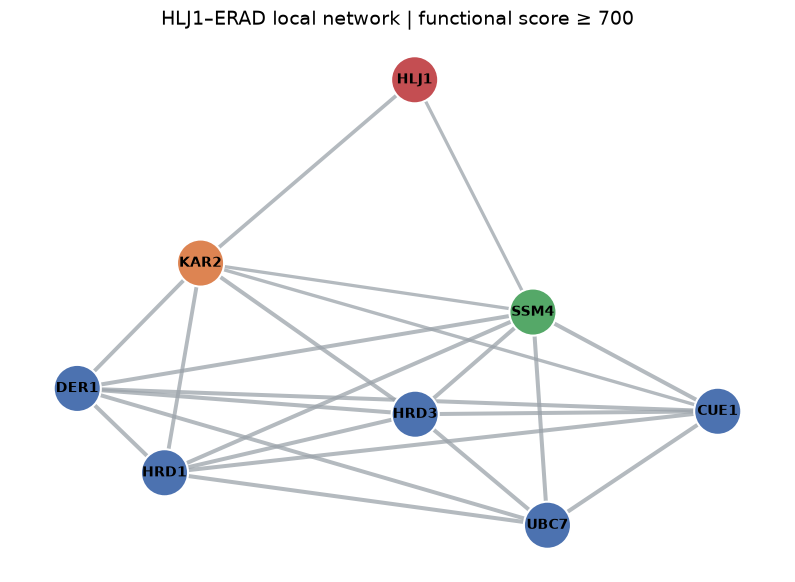

Saved: /Users/kennyyu/math3888-stream-2-group-k/figures/02_hlj1_erad_local_network.png


In [9]:
local_nodes = R | set(bridge_700)
local_graph = G.subgraph(local_nodes).copy()

positions = nx.spring_layout(
    local_graph,
    seed=3888,
    weight="confidence",
)

def node_colour(protein):
    if protein == h:
        return "#C44E52"      # HLJ1
    if protein in S:
        return "#4C72B0"      # Other core seeds
    if name_by_id.get(protein) == "KAR2":
        return "#DD8452"      # Prespecified readout
    return "#55A868"          # Other bridge proteins

fig, ax = plt.subplots(figsize=(10, 7))

nx.draw_networkx_edges(
    local_graph,
    positions,
    ax=ax,
    edge_color="#9BA3AA",
    width=[
        0.7 + 2.2 * local_graph[u][v]["confidence"]
        for u, v in local_graph.edges
    ],
    alpha=0.75,
)

nx.draw_networkx_nodes(
    local_graph,
    positions,
    ax=ax,
    node_color=[node_colour(v) for v in local_graph.nodes],
    node_size=1150,
    edgecolors="white",
    linewidths=1.5,
)

nx.draw_networkx_labels(
    local_graph,
    positions,
    labels={
        v: name_by_id.get(v, v)
        for v in local_graph.nodes
    },
    ax=ax,
    font_size=10,
    font_weight="bold",
)

ax.set_title(
    "HLJ1–ERAD local network | functional score ≥ 700",
    fontsize=14,
)
ax.axis("off")

figure_path = FIGURES / "02_hlj1_erad_local_network.png"
fig.savefig(figure_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

## 7. Validate and export the baseline results

Before interpreting rankings, verify that:

1. Every STRING protein has exactly one output row.
2. All five surviving seeds are reachable from HLJ1 in the primary functional graph.
3. PageRank scores each sum to one.
4. Jaccard and bridge scores stay within $[0,1]$.
5. The seed set used for personalized PageRank excludes HLJ1.

Inspect high-scoring proteins **by separate feature**, not by an arbitrary combined score. A large global hub, a protein close to one seed, and a protein bridging HLJ1 to several seeds answer different questions.

Expected outputs:

- `outputs/notebook_02/seed_pair_distances_functional_700.csv`
- `outputs/notebook_02/protein_baseline_features_functional_700.csv`
- `outputs/notebook_02/network_sensitivity_summary.csv`
- `outputs/notebook_02/run_record.json`
- `figures/02_hlj1_erad_local_network.png`

The next notebook will remove HLJ1 *in silico*, compare the same surviving seed set $S$ before and after deletion, and test pathway-efficiency loss against matched reference deletions.

In [10]:
assert len(profile) == len(id_map) == G.number_of_nodes()
assert profile["string_protein_id"].is_unique
assert h not in S
assert len(S) == 5

assert seed_distances["hop_distance"].notna().all()
assert np.isclose(sum(global_pagerank.values()), 1.0)
assert np.isclose(sum(seed_pagerank.values()), 1.0)

assert profile["jaccard_S_mean"].between(0, 1).all()
assert profile["jaccard_S_max"].between(0, 1).all()
assert profile["bridge_hS"].between(0, 1).all()

assert profile.loc[
    profile["is_core_seed"], "candidate_eligible"
].eq(False).all()

seed_distance_path = (
    OUTPUT / "seed_pair_distances_functional_700.csv"
)
profile_path = (
    OUTPUT / "protein_baseline_features_functional_700.csv"
)
sensitivity_path = (
    OUTPUT / "network_sensitivity_summary.csv"
)
run_record_path = OUTPUT / "run_record.json"

seed_distances.to_csv(seed_distance_path, index=False)
profile.to_csv(profile_path, index=False)
sensitivity_summary.to_csv(sensitivity_path, index=False)

run_record = {
    "notebook": "02_baseline_network",
    "frozen_design_sha256": sha256(DESIGN_PATH),
    "seed_table_sha256": sha256(SEED_PATH),
    "functional_processed_sha256": sha256(
        PROCESSED / "functional_edges_score_ge_400.csv.gz"
    ),
    "physical_processed_sha256": sha256(
        PROCESSED / "physical_edges_score_ge_400.csv.gz"
    ),
    "primary_threshold": 700,
    "sensitivity_thresholds": [400, 900],
    "pagerank_alpha": 0.85,
    "community_random_seed": 3888,
    "networkx_version": nx.__version__,
    "pandas_version": pd.__version__,
    "core_seed_string_ids": sorted(R),
    "personalized_pagerank_seed_ids": sorted(S),
}
run_record_path.write_text(
    json.dumps(run_record, indent=2),
    encoding="utf-8",
)

eligible = profile.loc[profile["candidate_eligible"]].copy()

print("Non-seed proteins on HLJ1-to-seed shortest paths:")
display(
    eligible.loc[eligible["bridge_hS"] > 0, [
        "orf",
        "preferred_name",
        "bridge_hS",
        "seed_pagerank",
        "jaccard_S_mean",
        "physical_direct_S_neighbours_700",
    ]]
    .sort_values("bridge_hS", ascending=False)
)

print("Highest personalized PageRank among eligible proteins:")
display(
    eligible.sort_values(
        "seed_pagerank", ascending=False
    ).head(10)[[
        "orf",
        "preferred_name",
        "seed_pagerank",
        "degree",
        "S_hops",
        "jaccard_S_mean",
        "bridge_hS",
    ]]
)

print("Saved:")
for path in [
    seed_distance_path,
    profile_path,
    sensitivity_path,
    run_record_path,
    figure_path,
]:
    print(path)

Non-seed proteins on HLJ1-to-seed shortest paths:


,orf,preferred_name,bridge_hS,seed_pagerank,jaccard_S_mean,physical_direct_S_neighbours_700
3022,YIL030C,SSM4,0.6,0.011052,0.380422,5


Highest personalized PageRank among eligible proteins:


,orf,preferred_name,seed_pagerank,degree,S_hops,jaccard_S_mean,bridge_hS
916,YDL126C,CDC48,0.012196,106,1.0,0.133732,0.0
2405,YGR048W,UFD1,0.011100,57,1.0,0.209805,0.0
3022,YIL030C,SSM4,0.011052,34,1.0,0.380422,0.6
4568,YML013W,UBX2,0.011033,31,1.0,0.323339,0.0
455,YBR170C,NPL4,0.010990,73,1.0,0.137807,0.0
1107,YDR057W,YOS9,0.010371,21,1.0,0.461286,0.0
4454,YLR378C,SEC61,0.010211,215,1.0,0.058911,0.0
4584,YML029W,USA1,0.010037,17,1.0,0.536519,0.0
1479,YDR411C,DFM1,0.009782,19,1.0,0.412676,0.0
5021,YMR297W,PRC1,0.007991,45,1.0,0.208173,0.0


Saved:
/Users/kennyyu/math3888-stream-2-group-k/outputs/notebook_02/seed_pair_distances_functional_700.csv
/Users/kennyyu/math3888-stream-2-group-k/outputs/notebook_02/protein_baseline_features_functional_700.csv
/Users/kennyyu/math3888-stream-2-group-k/outputs/notebook_02/network_sensitivity_summary.csv
/Users/kennyyu/math3888-stream-2-group-k/outputs/notebook_02/run_record.json
/Users/kennyyu/math3888-stream-2-group-k/figures/02_hlj1_erad_local_network.png
